<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/K_Mean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Mean


## Problem Statement

The goal of this project is to use K-Means clustering to group cricket players based on their performance statistics such as batting average, strike rate, and experience.

Clustering helps identify similar player profiles without predefined labels.

## Project Workflow

1. Load Dataset
2. Data Understanding
3. Data Cleaning
4. Feature Engineering
5. Feature Scaling
6. Determine Optimal Clusters
7. Apply K-Means
8. Cluster Analysis
9. Visualization
10. Insights

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Cricket.csv to Cricket (1).csv


# Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load dataset

In [3]:
data = pd.read_csv("Cricket.csv",encoding = "latin1")

In [4]:
data.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28


# Basic Data Exploration

In [5]:
data.shape

(79, 13)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


In [7]:
data.describe()

,Mat,Inns,NO,Runs,Ave,BF,SR,100,50,0
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,245.075949,230.544304,30.037975,7618.139241,38.523291,9684.455696,79.295316,11.556962,46.443038,13.253165
std,74.211716,70.321022,14.421710,2551.873313,5.919093,3193.835825,9.925307,8.092014,16.351701,5.925755
min,128.000000,127.000000,4.000000,5080.000000,23.570000,5504.000000,60.570000,0.000000,23.000000,3.000000
25%,188.000000,177.000000,17.500000,5759.000000,34.600000,7393.500000,73.725000,6.000000,34.500000,9.000000
50%,232.000000,217.000000,29.000000,6798.000000,37.870000,9134.000000,77.730000,10.000000,42.000000,13.000000
75%,281.500000,261.500000,40.000000,8739.500000,41.845000,10976.000000,85.180000,15.500000,54.000000,16.000000
max,463.000000,452.000000,70.000000,18426.000000,53.940000,21367.000000,117.000000,49.000000,96.000000,34.000000


In [8]:
data.isnull().sum()

,0
Player,0
Span,0
Mat,0
Inns,0
NO,0
Runs,0
HS,0
Ave,0
BF,0
SR,0


In [9]:
data.columns

Index(['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR',
       '100', '50', '0'],
      dtype='object')

In [10]:
data.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28


# Feature Engineering (Convert Span → Experience)

In [11]:
data["start_year"] = data["Span"].str.split("-").str[0].astype(int)
data["End_year"] =data["Span"].str.split("-").str[1].astype(int)

data["Experience"] = data["End_year"] - data["start_year"]

In [12]:
data

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start_year,End_year,Experience
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3,1975,1991,16
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6,2002,2015,13
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7,2001,2011,10
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009,11


In [13]:
data = data.drop(["Span","start_year","End_year"],axis = 1)

In [14]:
data

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,SR Tendulkar (INDIA),463,452,41,18426,200*,44.83,21367,86.23,49,96,20,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),128,127,13,5134,133*,45.03,7908,64.92,11,31,3,16
75,Misbah-ul-Haq (PAK),162,149,31,5122,96*,43.40,6945,73.75,0,42,6,13
76,PD Collingwood (ENG),197,181,37,5092,120*,35.36,6614,76.98,5,26,7,10
77,A Symonds (AUS),198,161,33,5088,156,39.75,5504,92.44,6,30,15,11


# Dealing the HS column

\d+ will extract the numeric value out the string

In [15]:
data["HS"].value_counts()

,count
HS,
120*,3
145,3
131*,3
119*,3
169,2
...,...
264,1
144*,1
150*,1


In [16]:
data.HS = data.HS.str.extract("(\d+)")
data.HS = data.HS.astype(int)

In [17]:
data["HS"].value_counts()

,count
HS,
145,5
119,4
144,3
183,3
150,3
131,3
120,3
141,3
153,2


In [18]:
data.isnull().sum()

,0
Player,0
Mat,0
Inns,0
NO,0
Runs,0
HS,0
Ave,0
BF,0
SR,0
100,0


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      79 non-null     object 
 1   Mat         79 non-null     int64  
 2   Inns        79 non-null     int64  
 3   NO          79 non-null     int64  
 4   Runs        79 non-null     int64  
 5   HS          79 non-null     int64  
 6   Ave         79 non-null     float64
 7   BF          79 non-null     int64  
 8   SR          79 non-null     float64
 9   100         79 non-null     int64  
 10  50          79 non-null     int64  
 11  0           79 non-null     int64  
 12  Experience  79 non-null     int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 8.2+ KB


#Data visualization

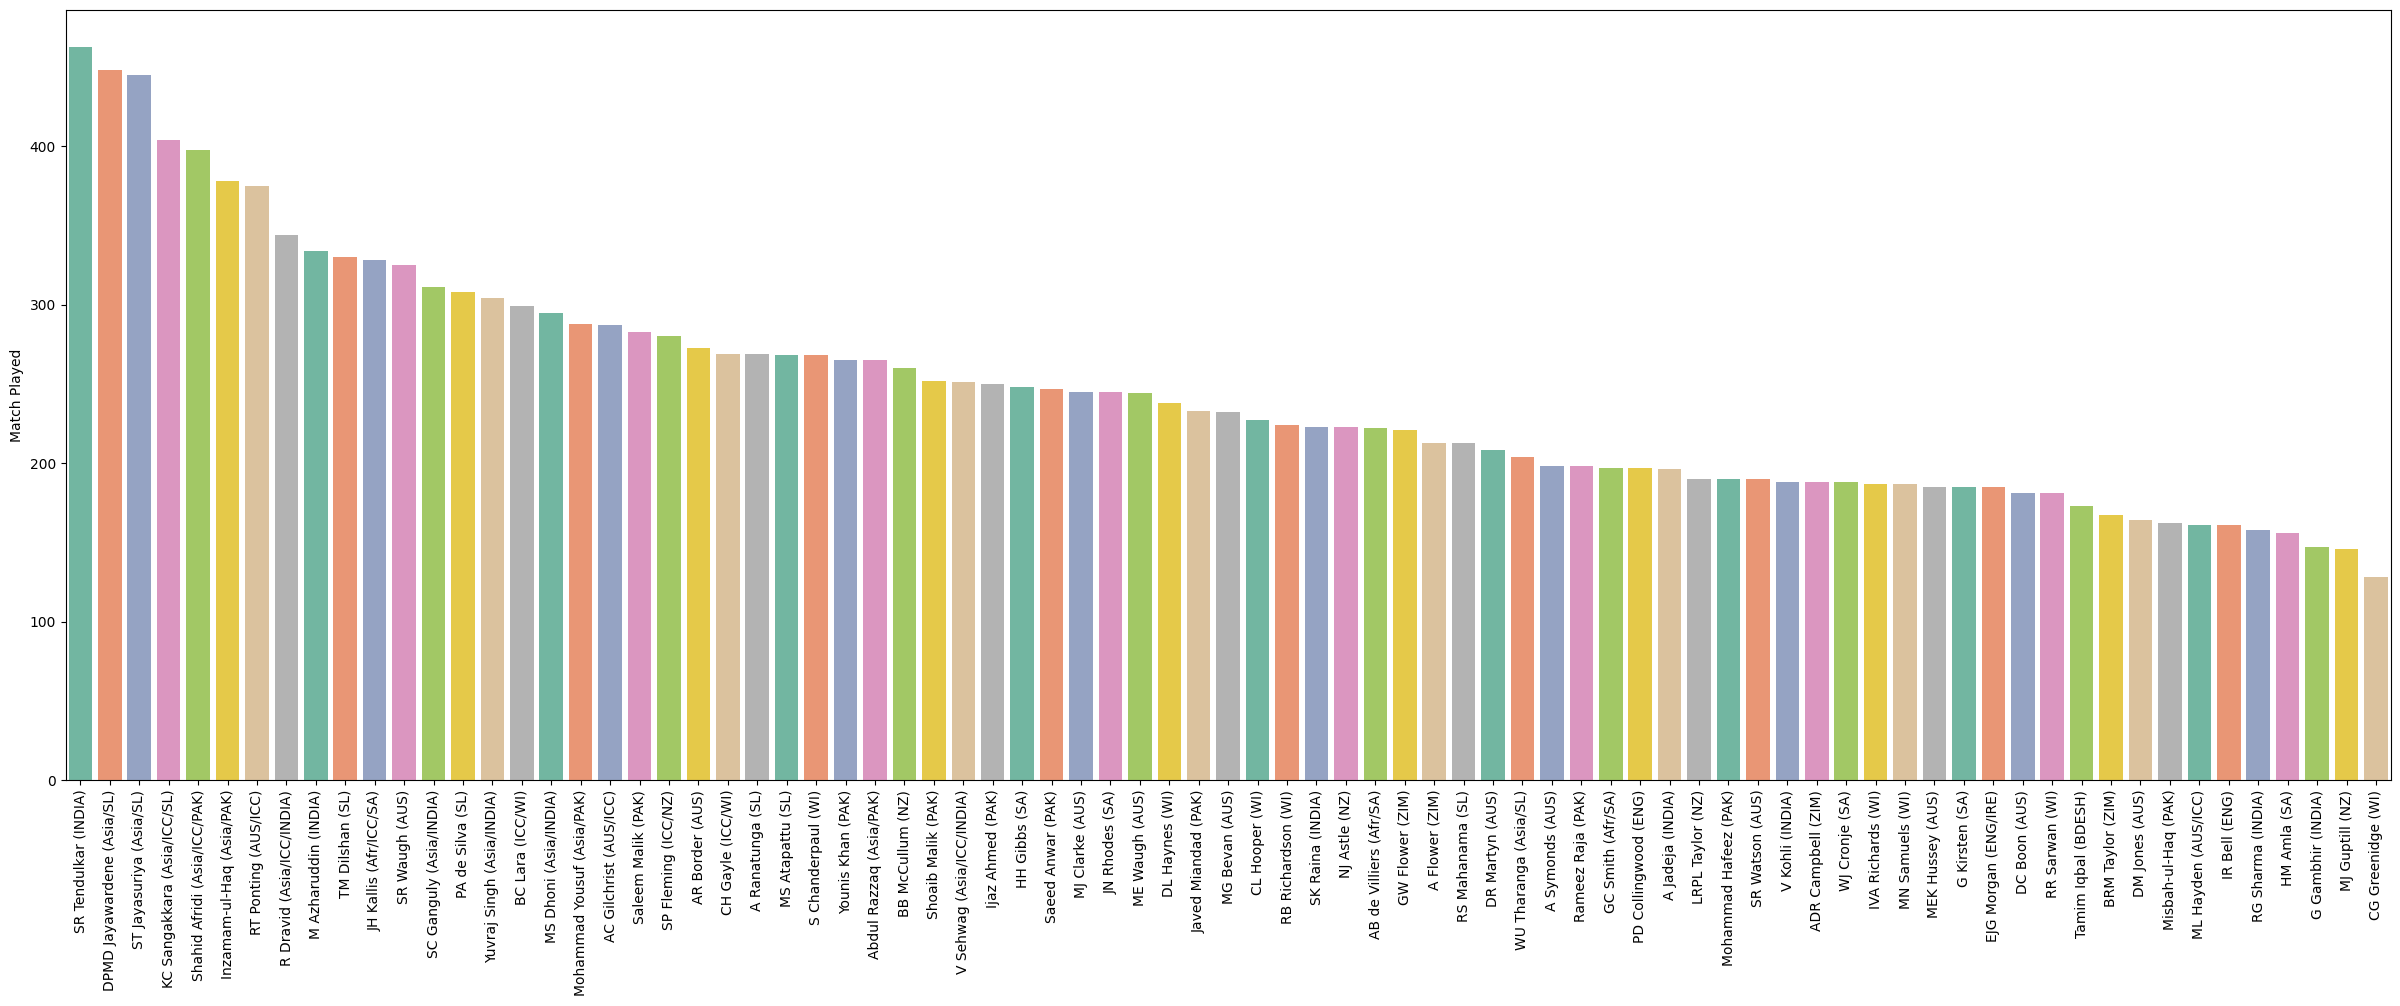

In [23]:
plt.figure(figsize = (30,10))
mat = data[["Player","Mat"]].sort_values("Mat",ascending = False)
ax = sns.barplot(x = "Player", y = "Mat",data = mat,palette = "Set2")
ax.set(xlabel= "",ylabel = "Match Played")
plt.xticks(rotation = 90)
plt.show()

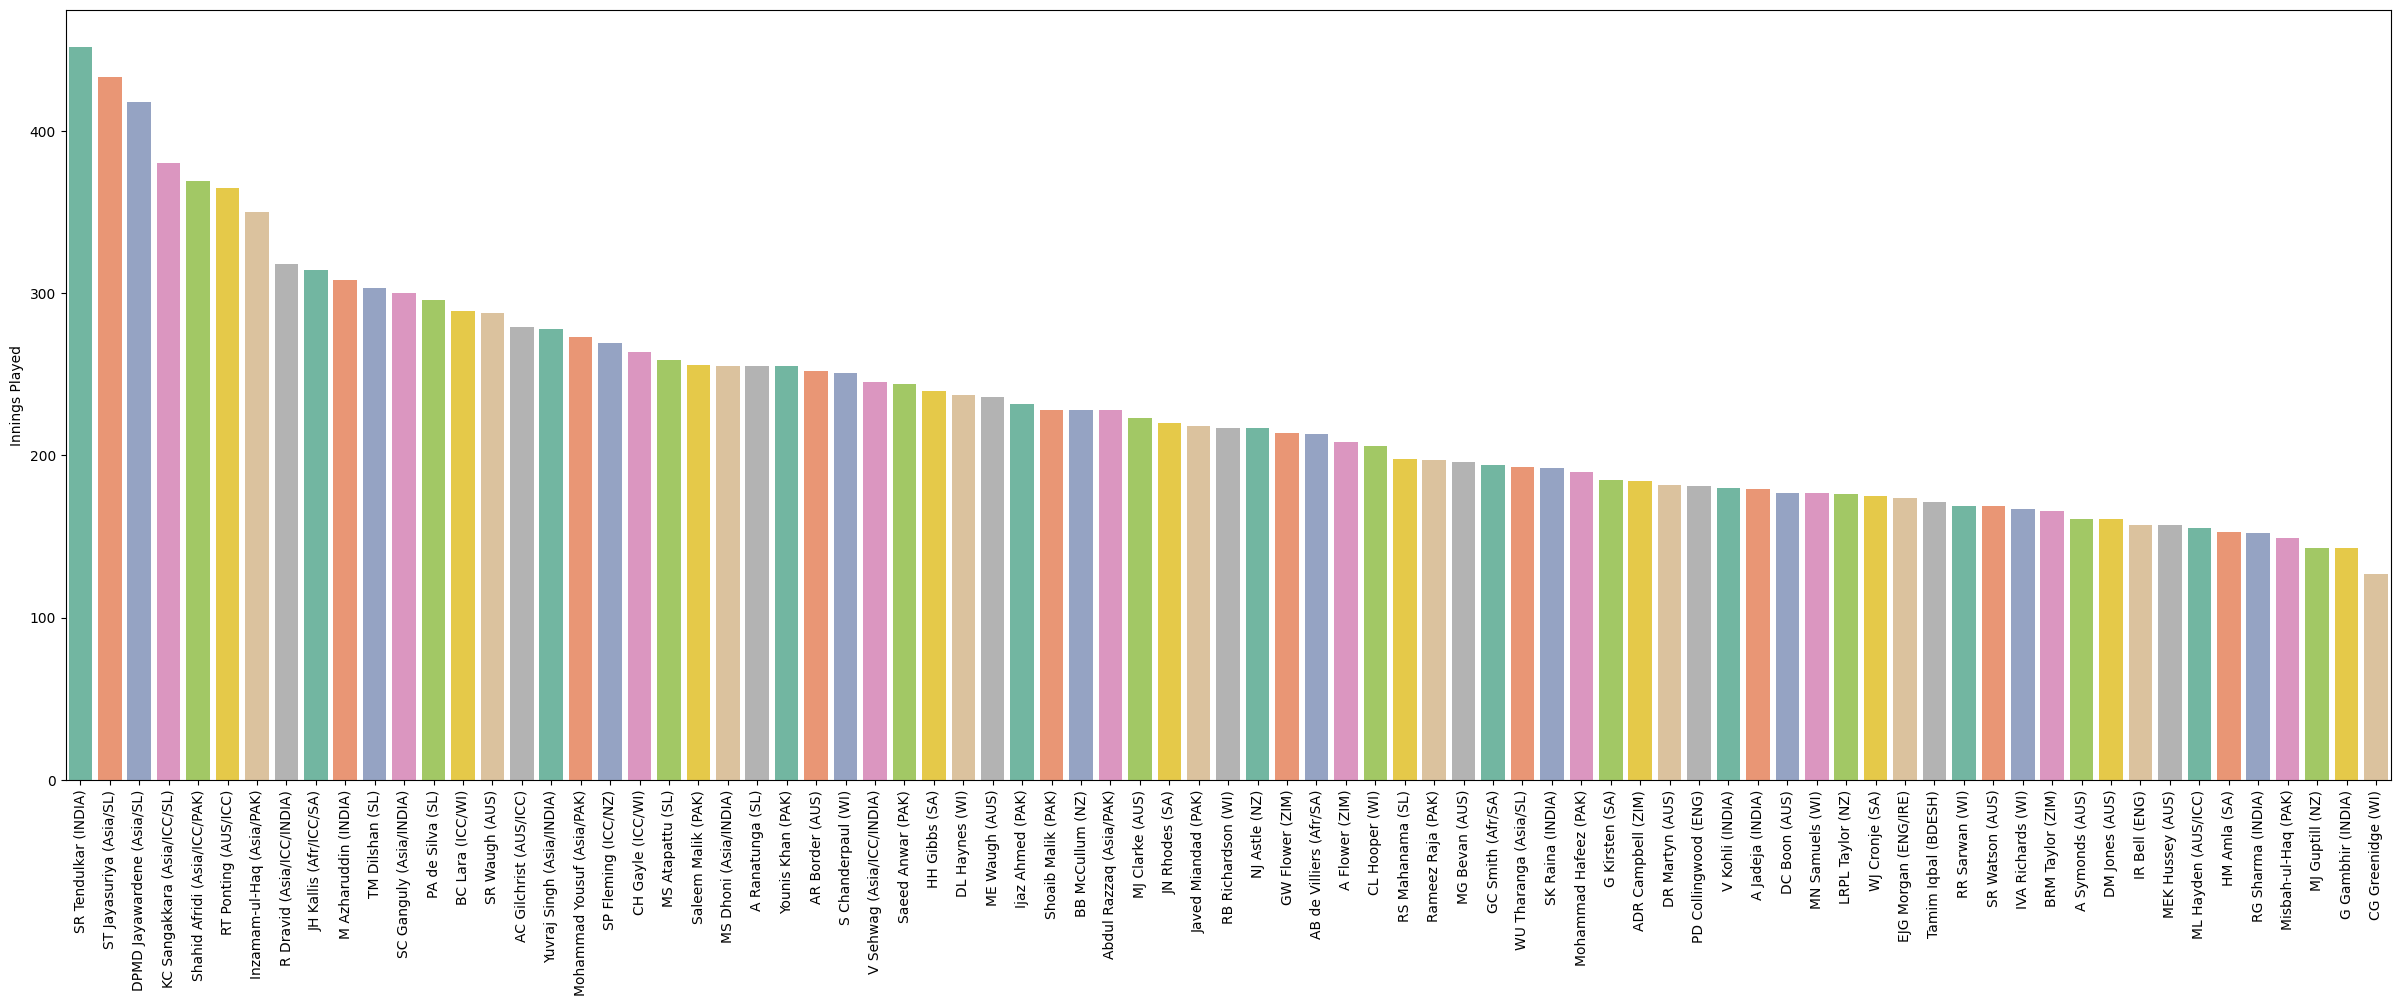

In [26]:
plt.figure(figsize = (30,10))
inns = data[["Player","Inns"]].sort_values("Inns",ascending = False)
ax = sns.barplot(x= "Player",y = "Inns",data = inns,palette = "Set2")
ax.set(xlabel = "",ylabel = "Innings Played")
plt.xticks(rotation = 90)
plt.show()

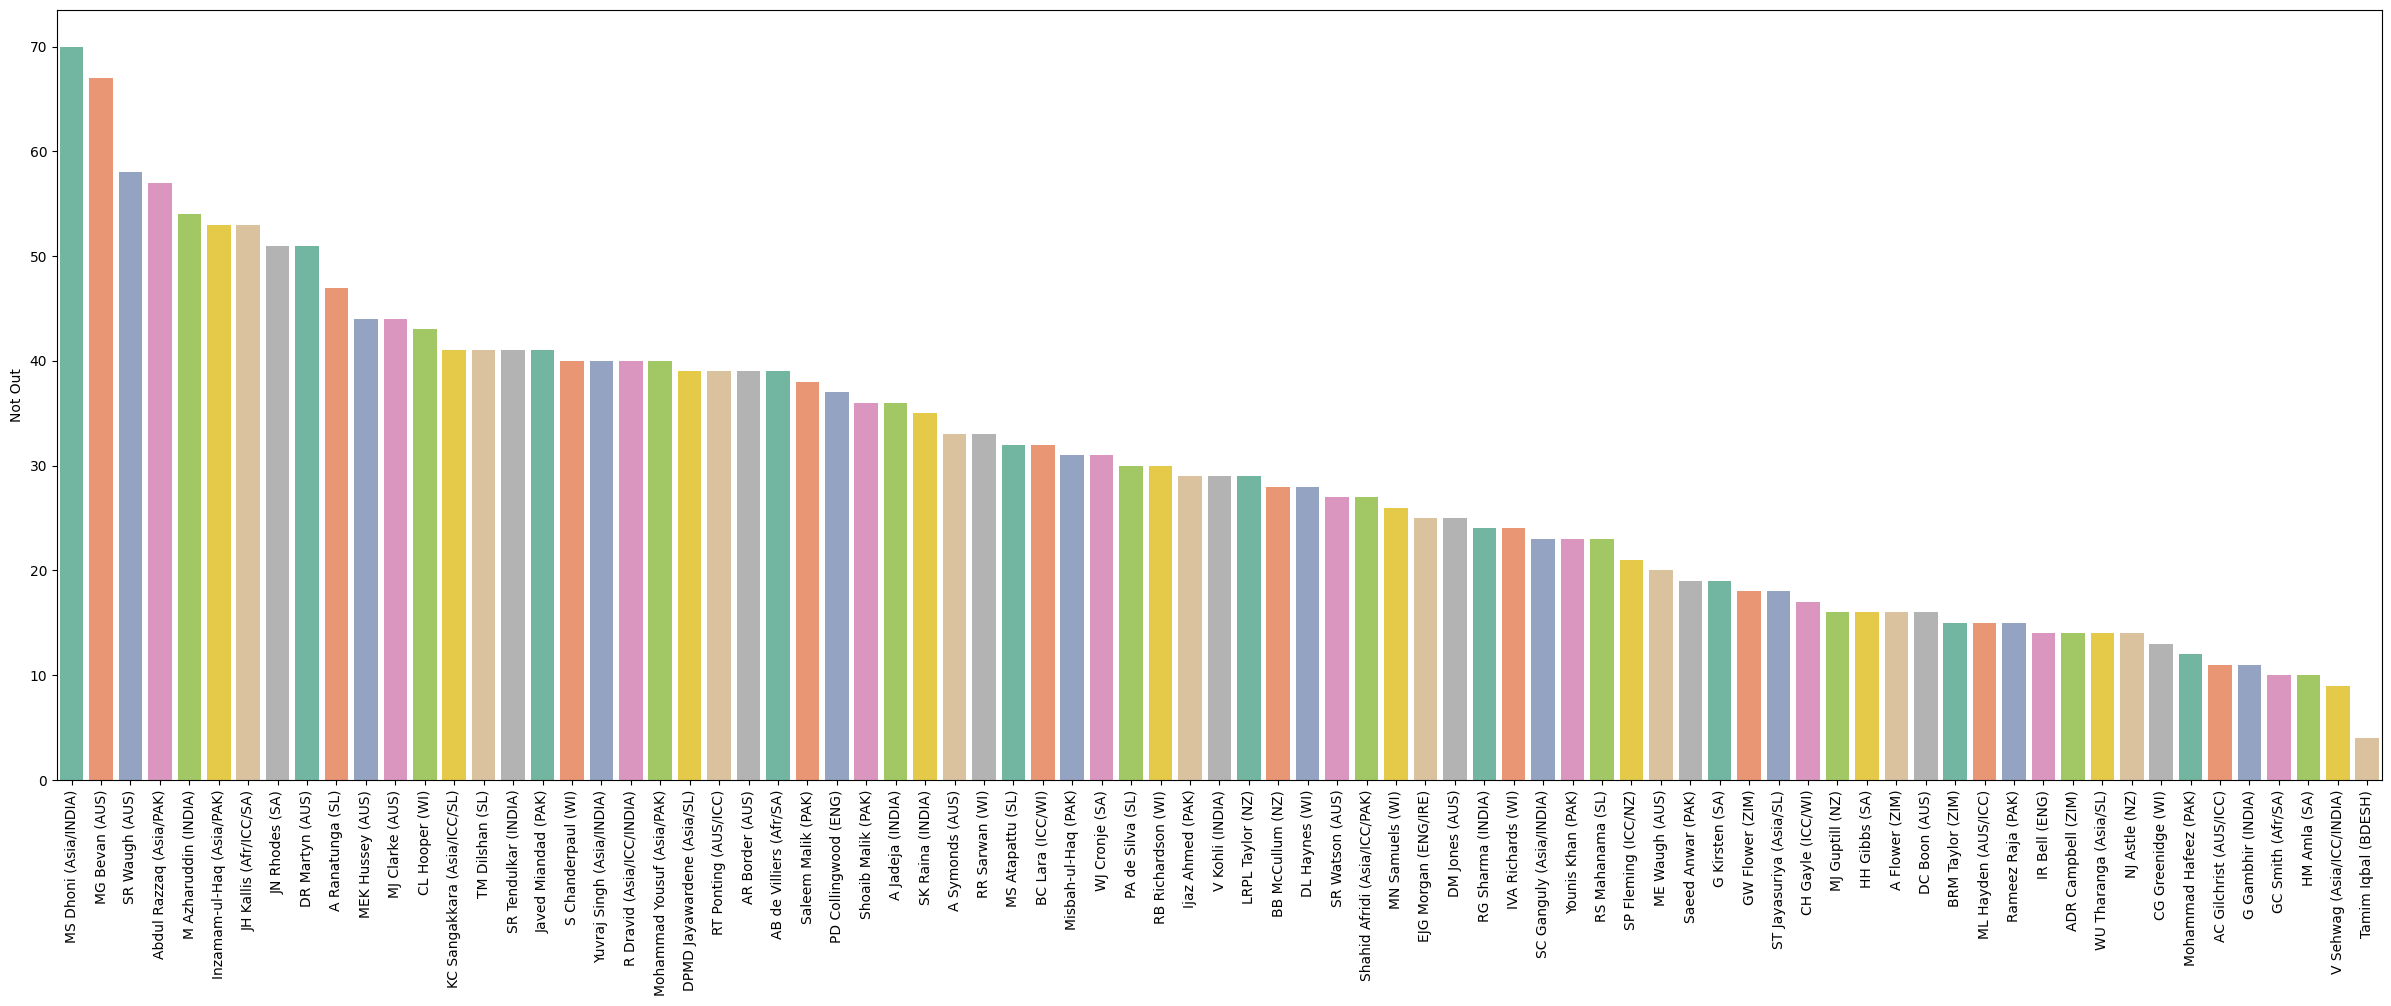

In [31]:
plt.figure(figsize = (30,10))
no = data[["Player","NO"]].sort_values("NO",ascending = False)
ax = sns.barplot(x = "Player",y = "NO",data = no,palette = "Set2")
ax.set(xlabel = "",ylabel = "Not Out")
plt.xticks(rotation = 90)
plt.show()

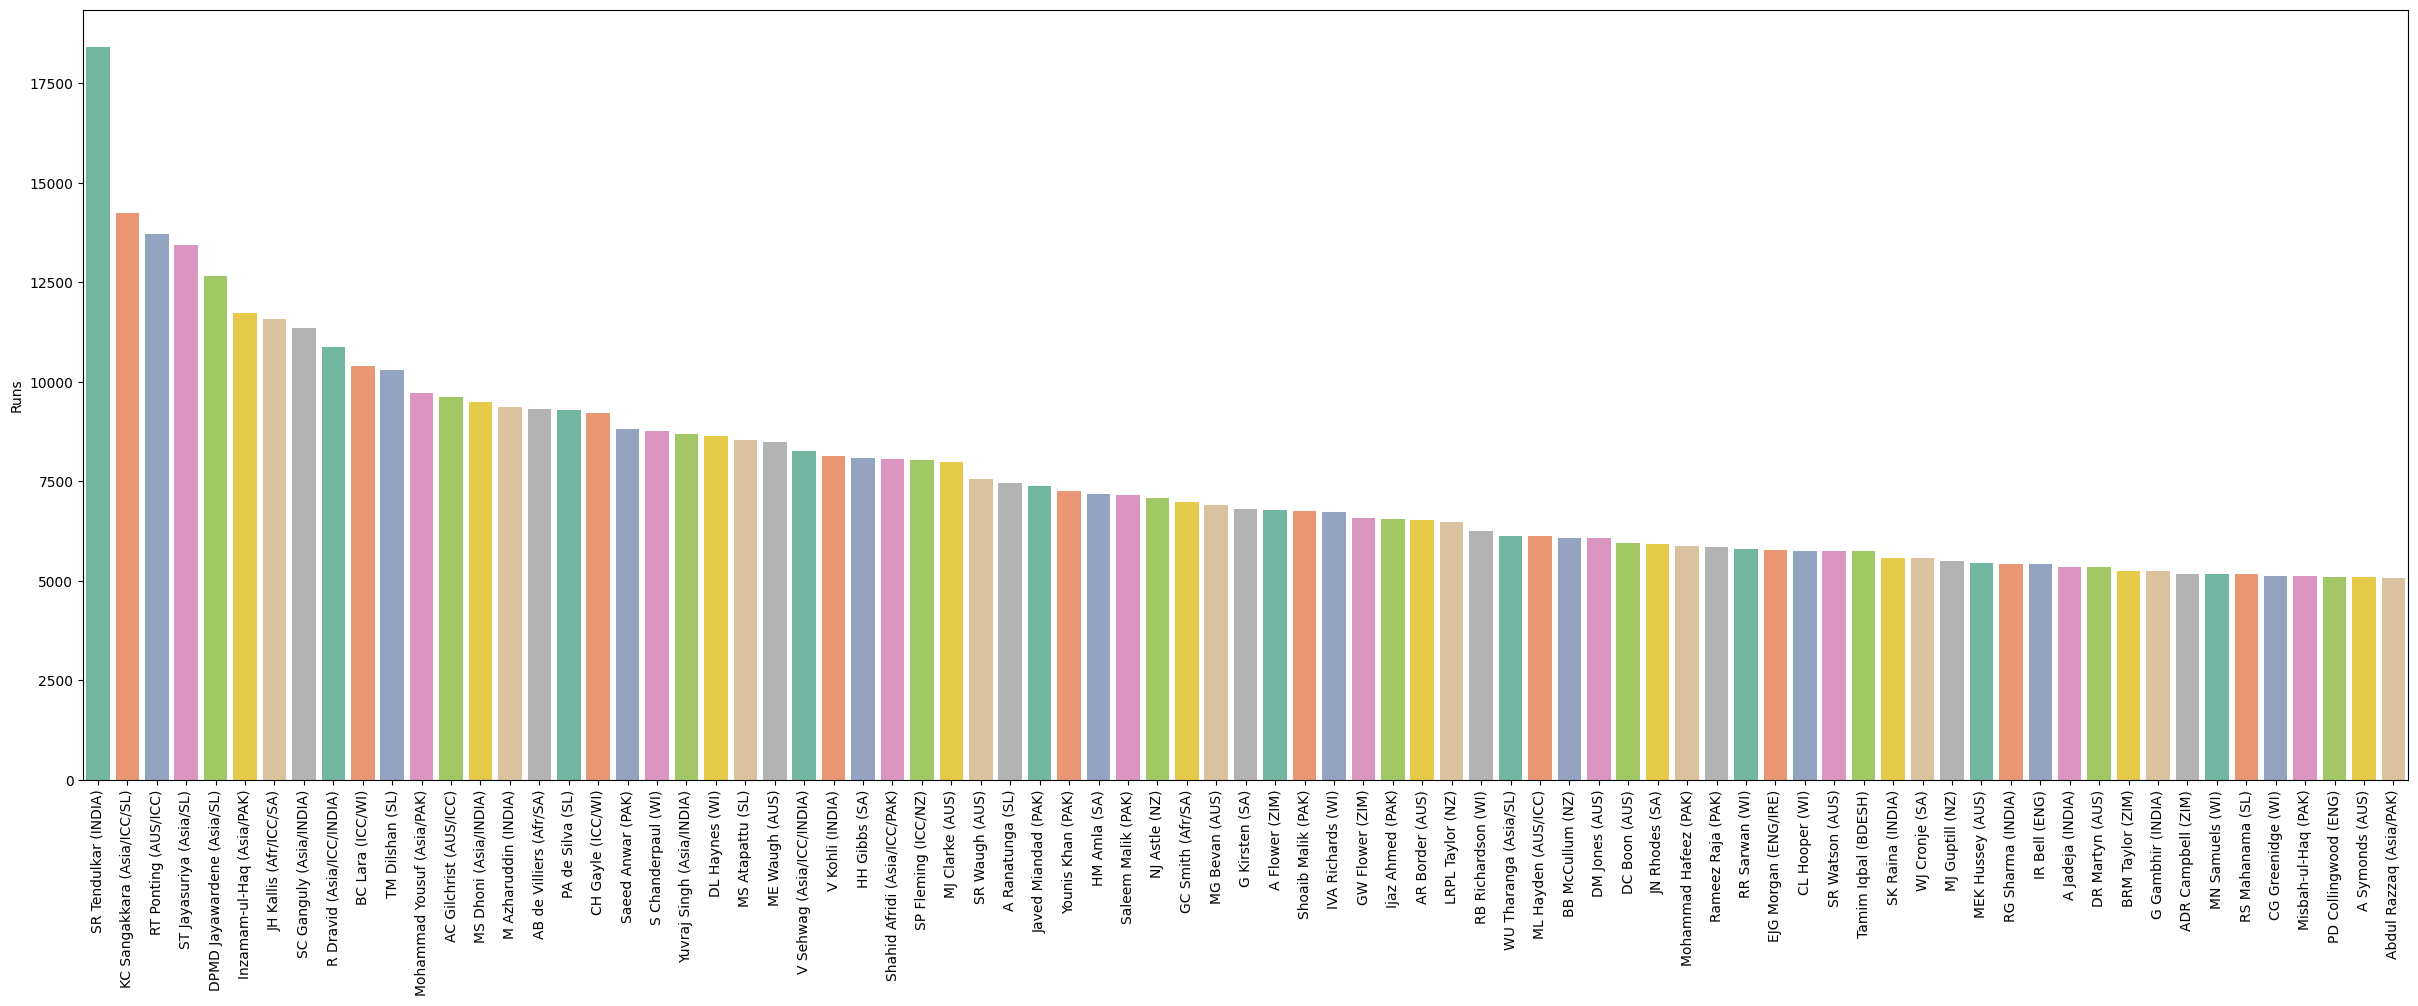

In [32]:
plt.figure(figsize = (30,10))
runs = data[["Player","Runs"]].sort_values("Runs",ascending = False)
ax = sns.barplot(x = "Player",y = "Runs",data = runs,palette = "Set2")
ax.set(xlabel = "",ylabel = "Runs")
plt.xticks(rotation = 90)
plt.show()

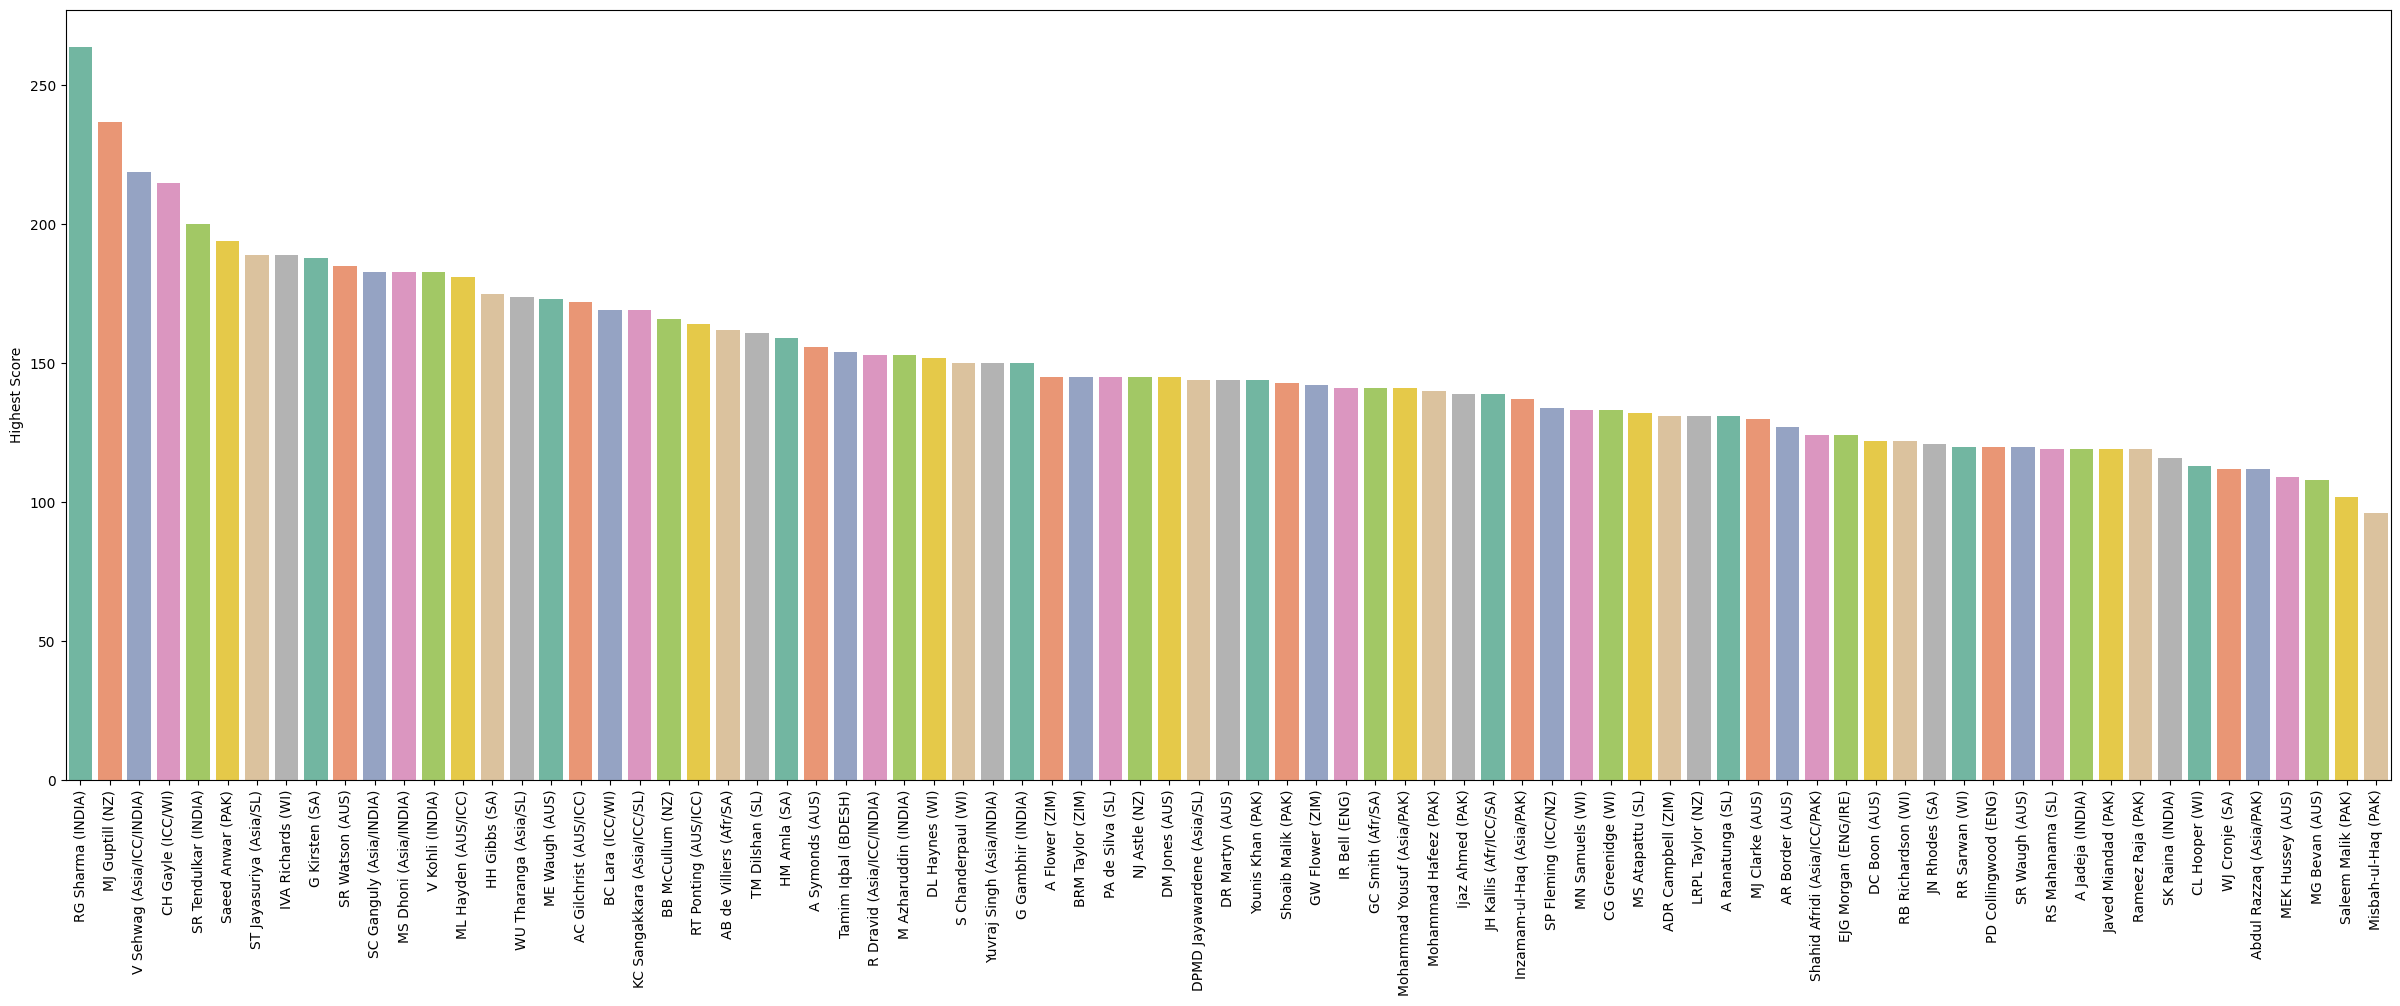

In [33]:
plt.figure(figsize = (30,10))
Hs = data[["Player","HS"]].sort_values("HS",ascending = False)
ax = sns.barplot(x = "Player",y = "HS",data = Hs,palette = "Set2")
ax.set(xlabel = "",ylabel = "Highest Score")
plt.xticks(rotation = 90)
plt.show()

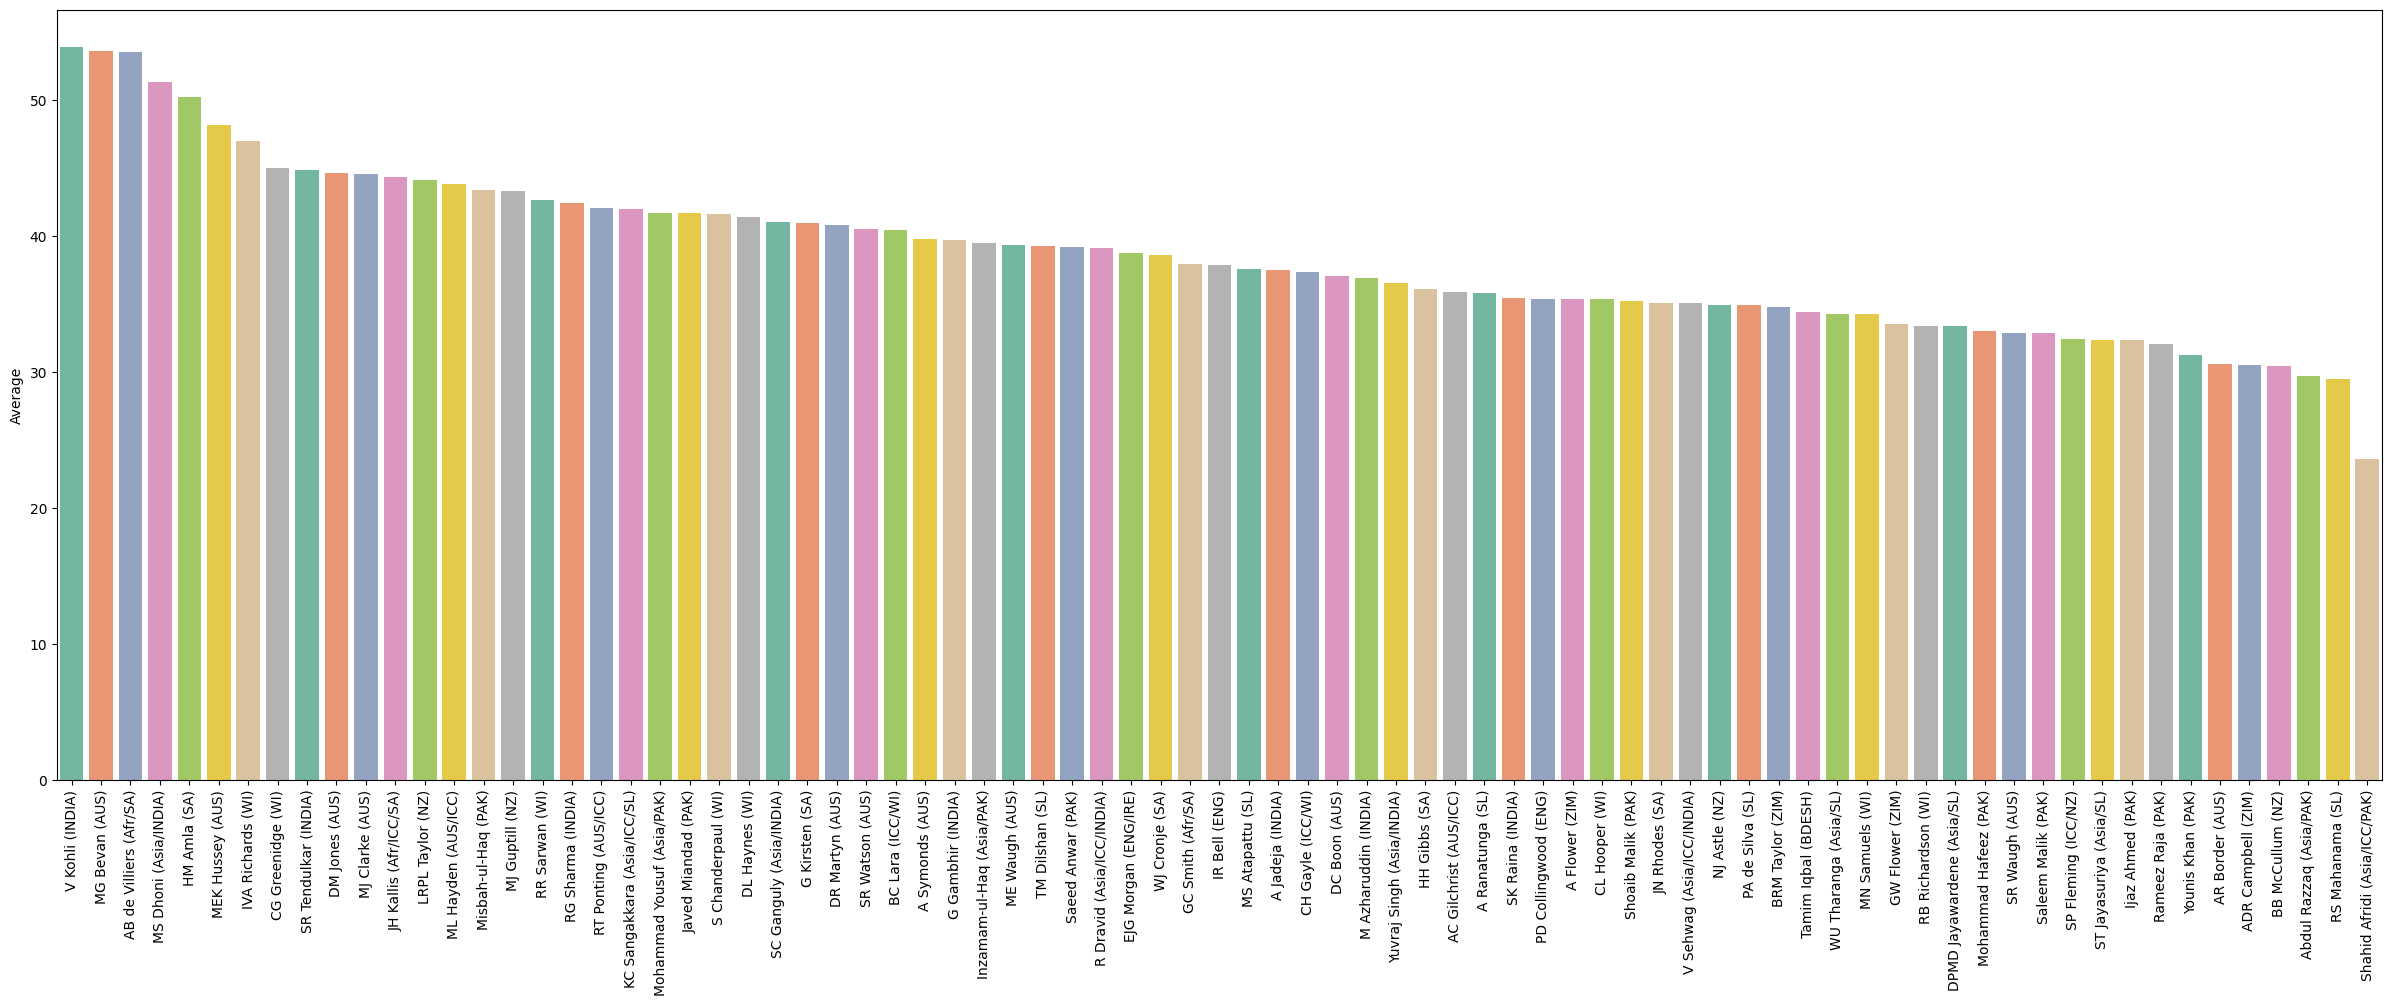

In [34]:
plt.figure(figsize = (30,10))
ave = data[["Player","Ave"]].sort_values("Ave",ascending = False)
ax = sns.barplot(x = "Player",y = "Ave",data = ave,palette = "Set2")
ax.set(xlabel = "",ylabel = "Average")
plt.xticks(rotation = 90)
plt.show()

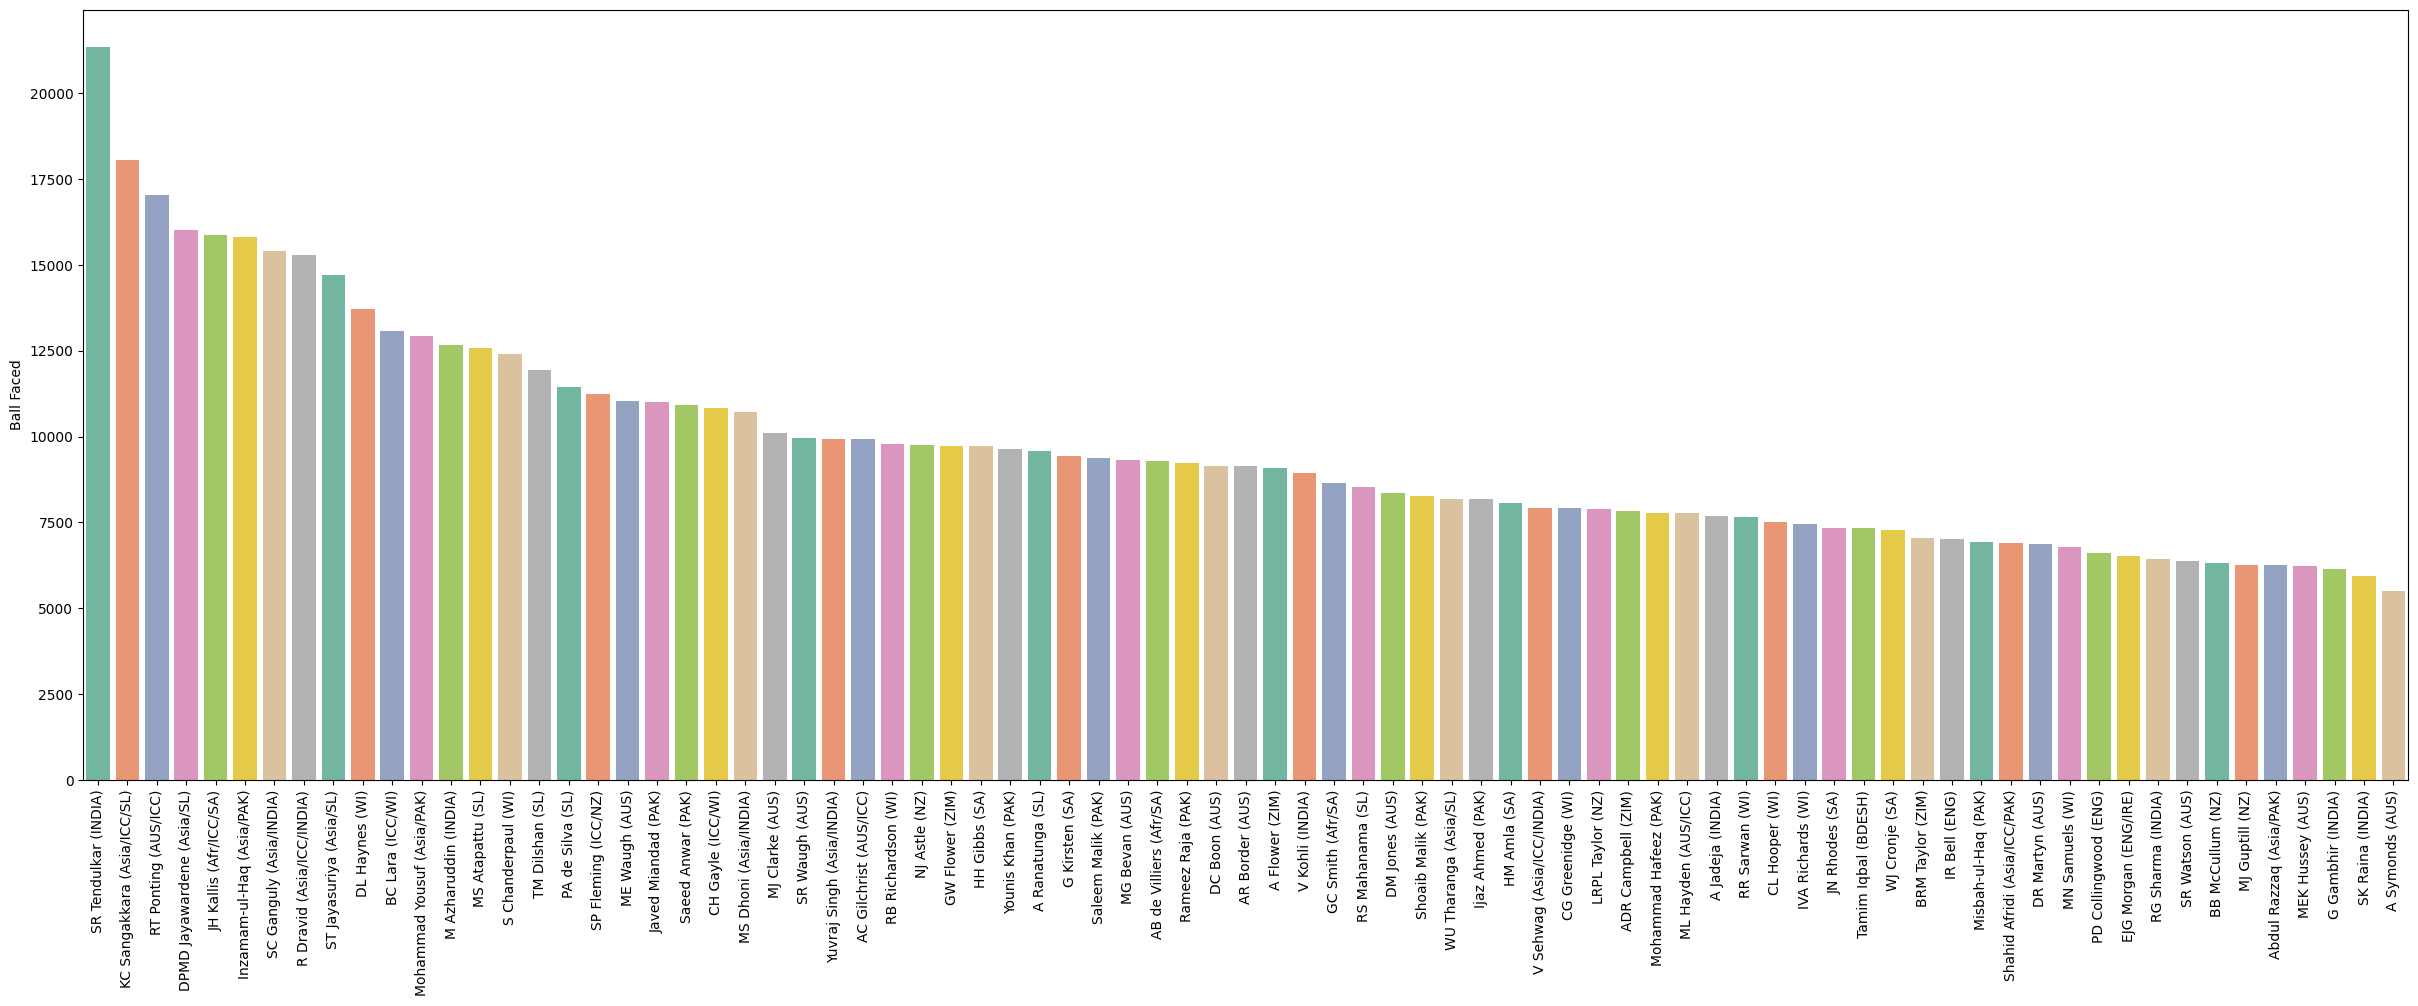

In [36]:
plt.figure(figsize = (30,10))
bf = data[["Player","BF"]].sort_values("BF",ascending = False)
ax = sns.barplot(x = "Player",y = "BF",data = bf,palette = "Set2")
ax.set(xlabel = "",ylabel = "Ball Faced")
plt.xticks(rotation = 90)
plt.show()

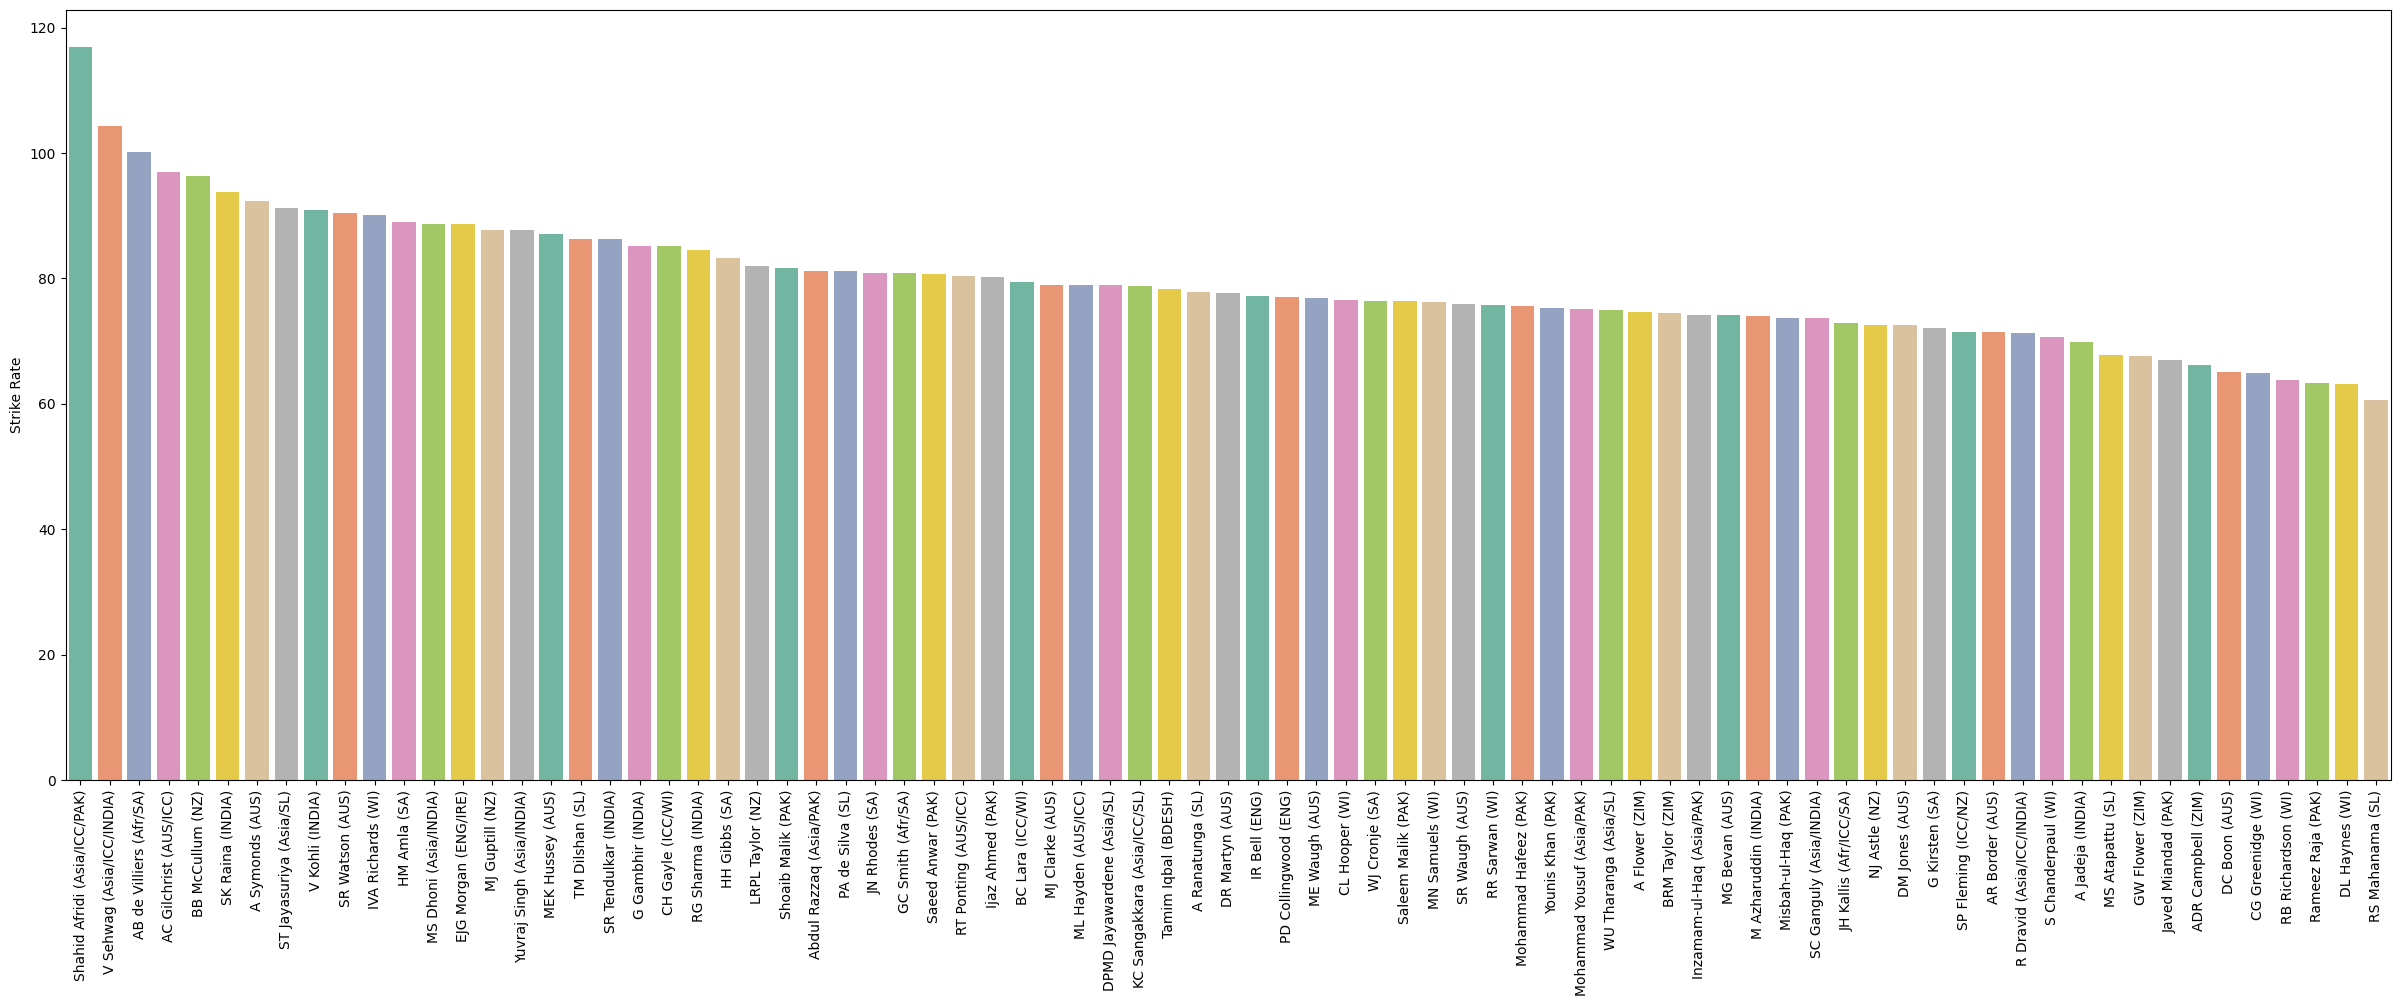

In [38]:
plt.figure(figsize =(30,10))
sr = data[["Player","SR"]].sort_values("SR",ascending = False)
ax = sns.barplot(x = "Player",y = "SR",data = sr,palette = "Set2")
ax.set(xlabel = "",ylabel = "Strike Rate")
plt.xticks(rotation = 90)
plt.show()

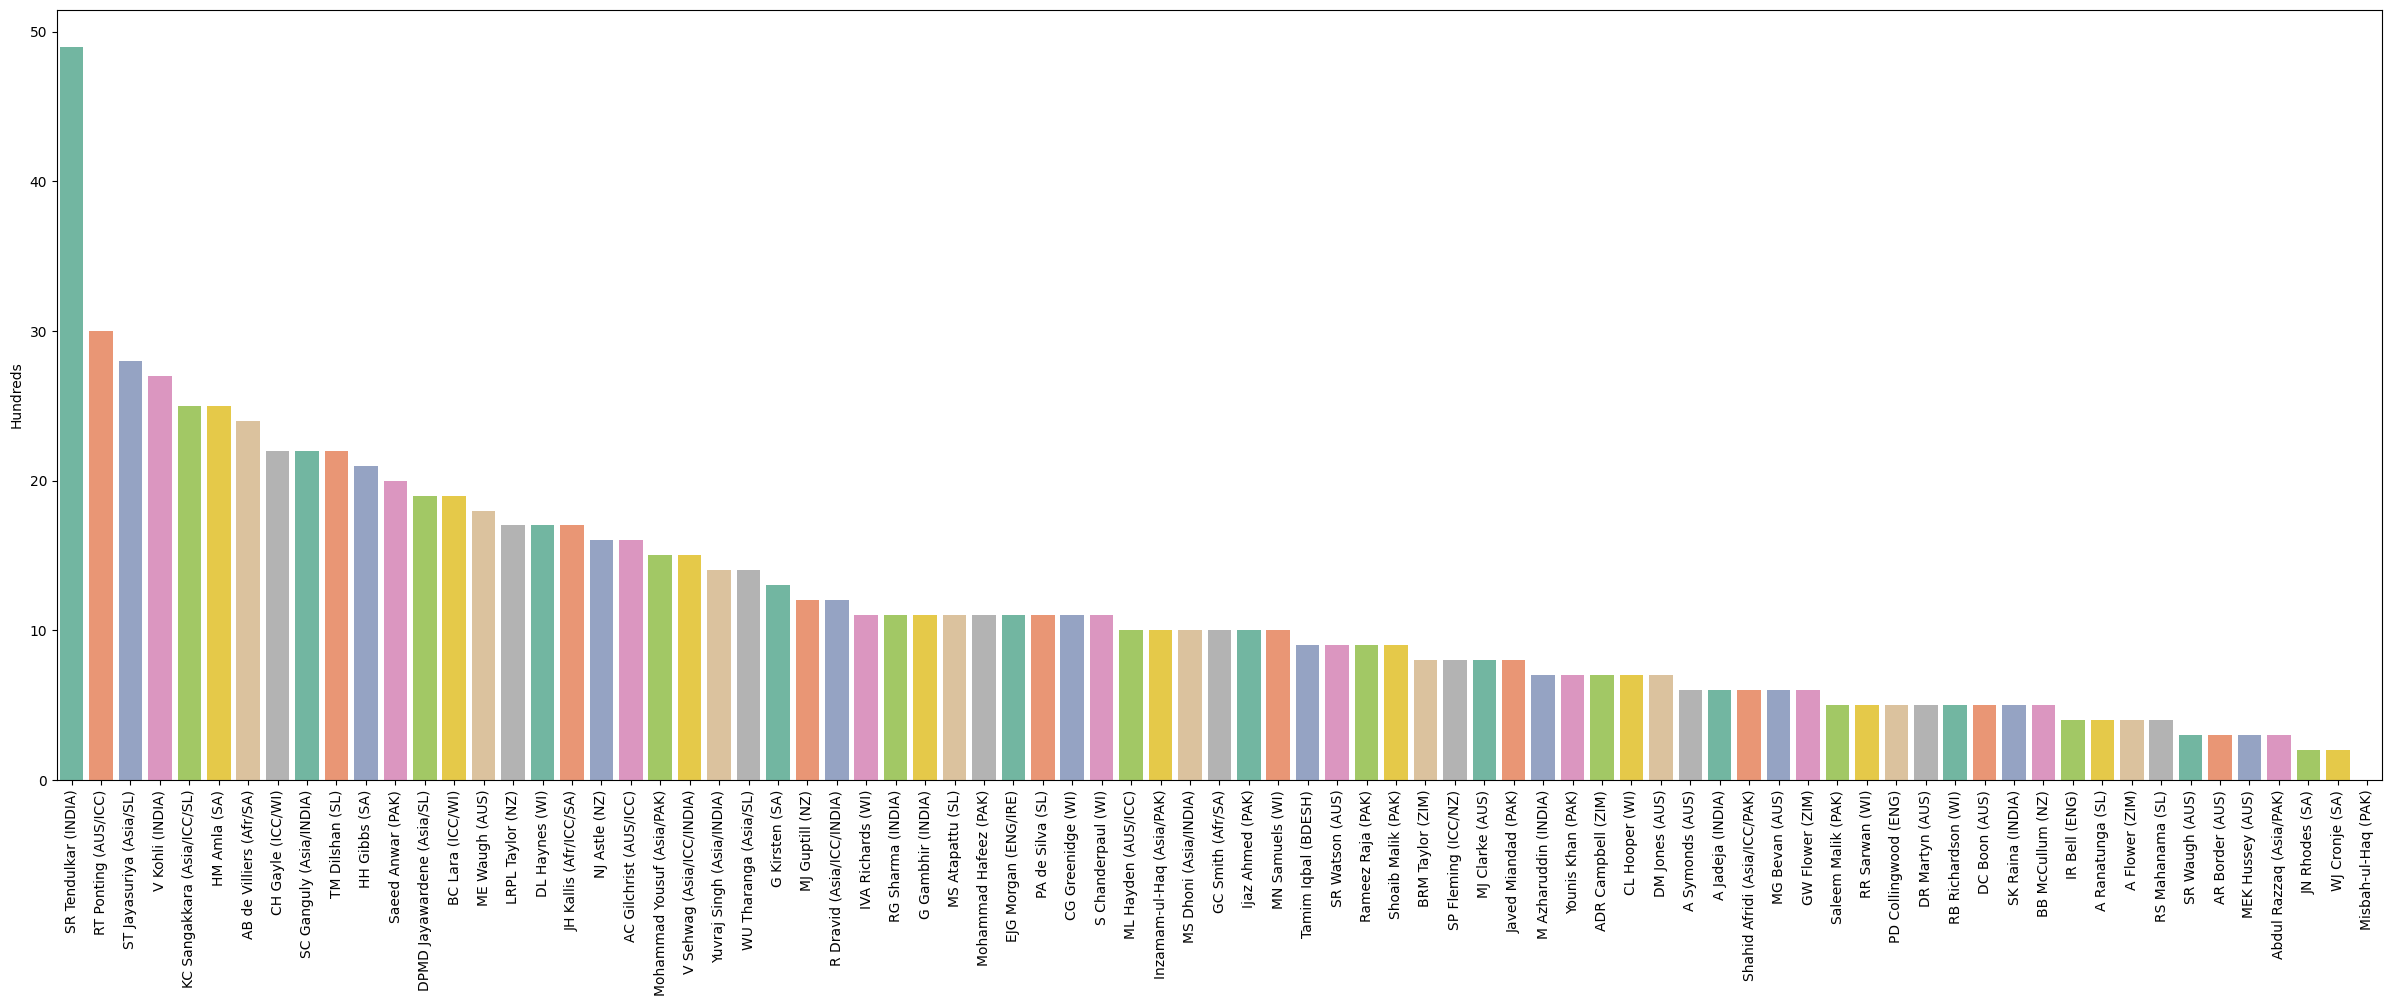

In [39]:
plt.figure(figsize =(30,10))
Hundred = data[["Player","100"]].sort_values("100",ascending = False)
ax = sns.barplot(x = "Player",y = "100",data = Hundred,palette = "Set2")
ax.set(xlabel = "",ylabel = "Hundreds")
plt.xticks(rotation = 90)
plt.show()

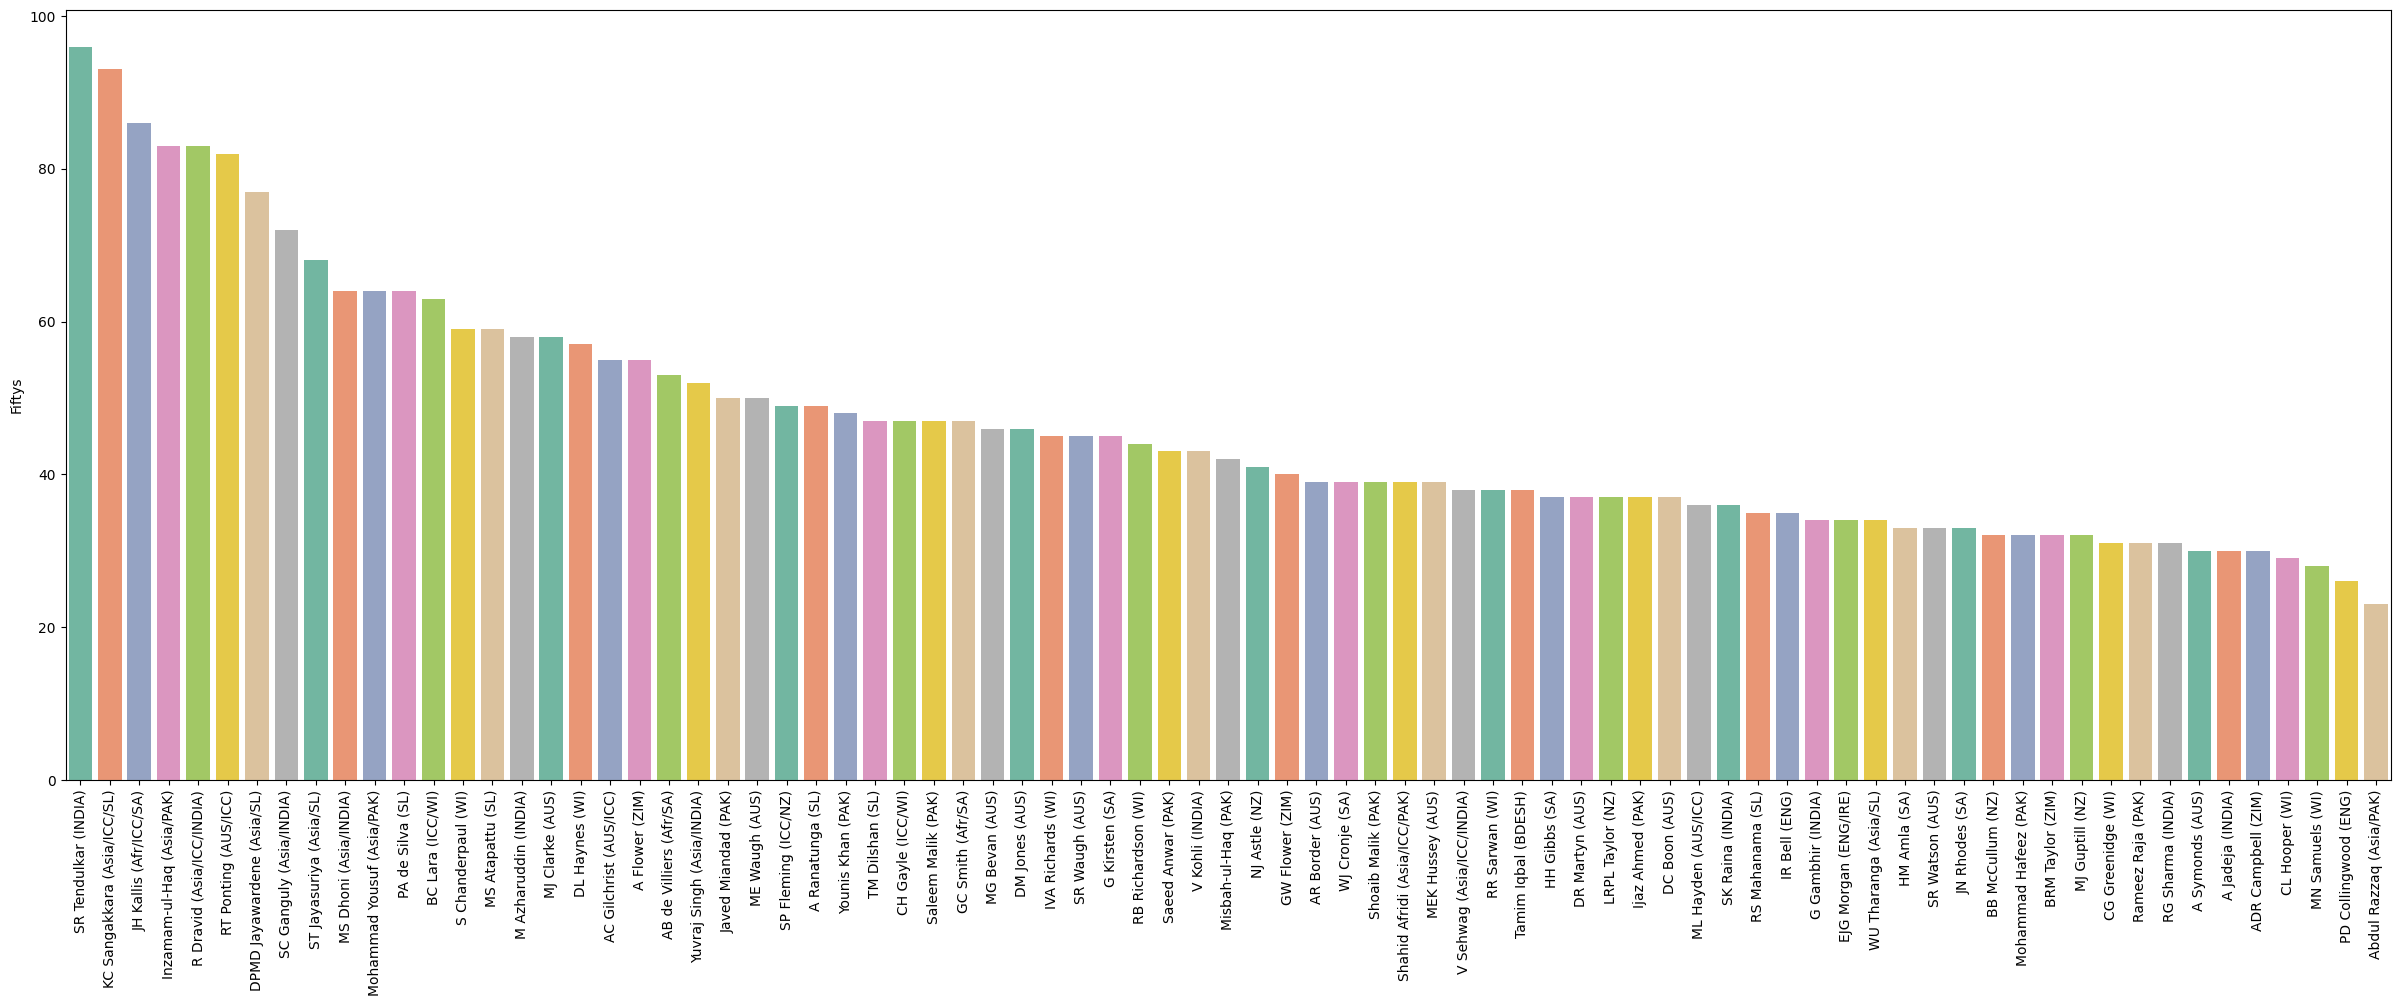

In [41]:
plt.figure(figsize =(30,10))
fifty = data[["Player","50"]].sort_values("50",ascending = False)
ax = sns.barplot(x = "Player",y = "50",data = fifty,palette = "Set2")
ax.set(xlabel = "",ylabel = "Fiftys")
plt.xticks(rotation = 90)
plt.show()

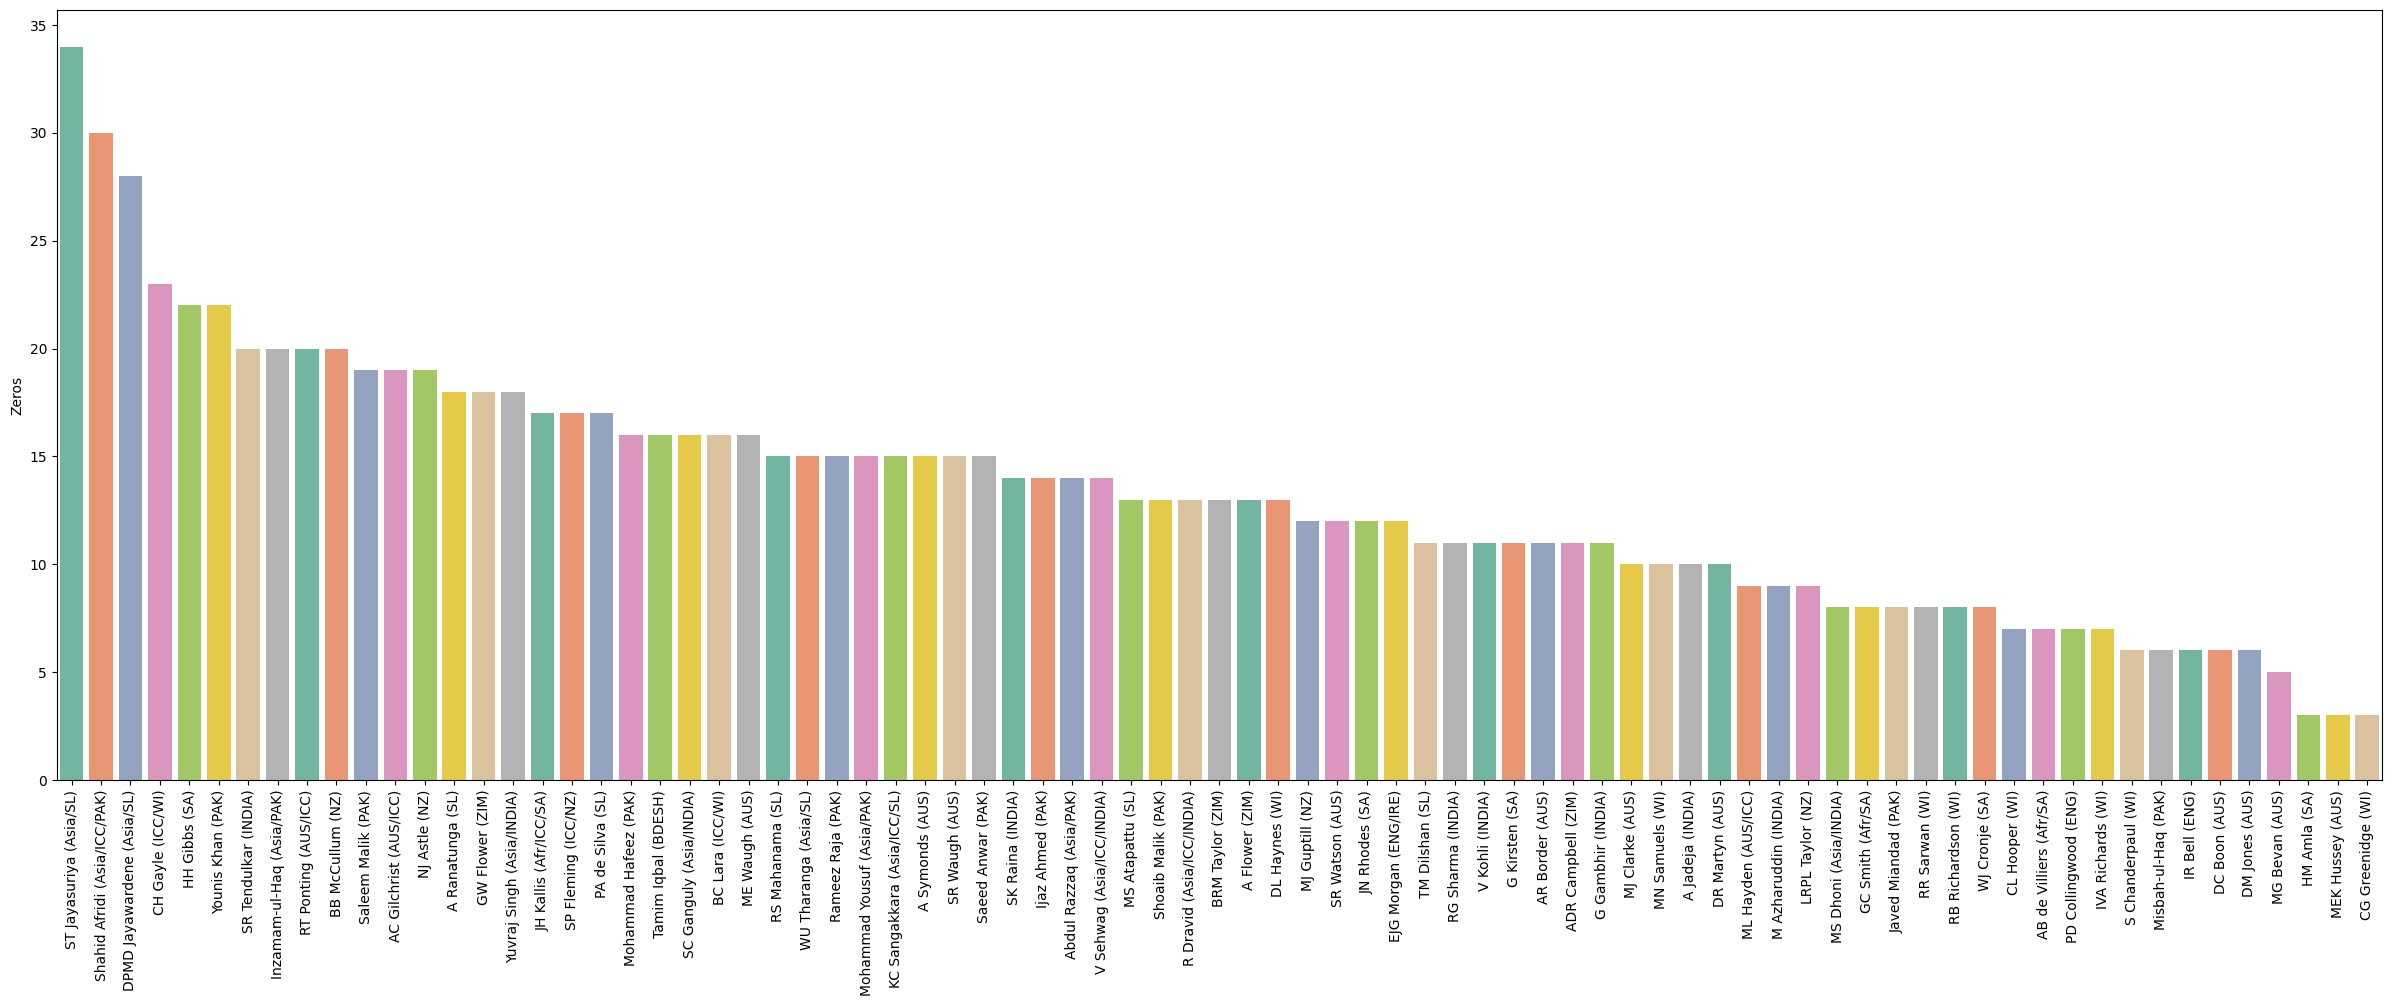

In [42]:
plt.figure(figsize =(30,10))
Zeros = data[["Player","0"]].sort_values("0",ascending = False)
ax = sns.barplot(x = "Player",y = "0",data = Zeros,palette = "Set2")
ax.set(xlabel = "",ylabel = "Zeros")
plt.xticks(rotation = 90)
plt.show()

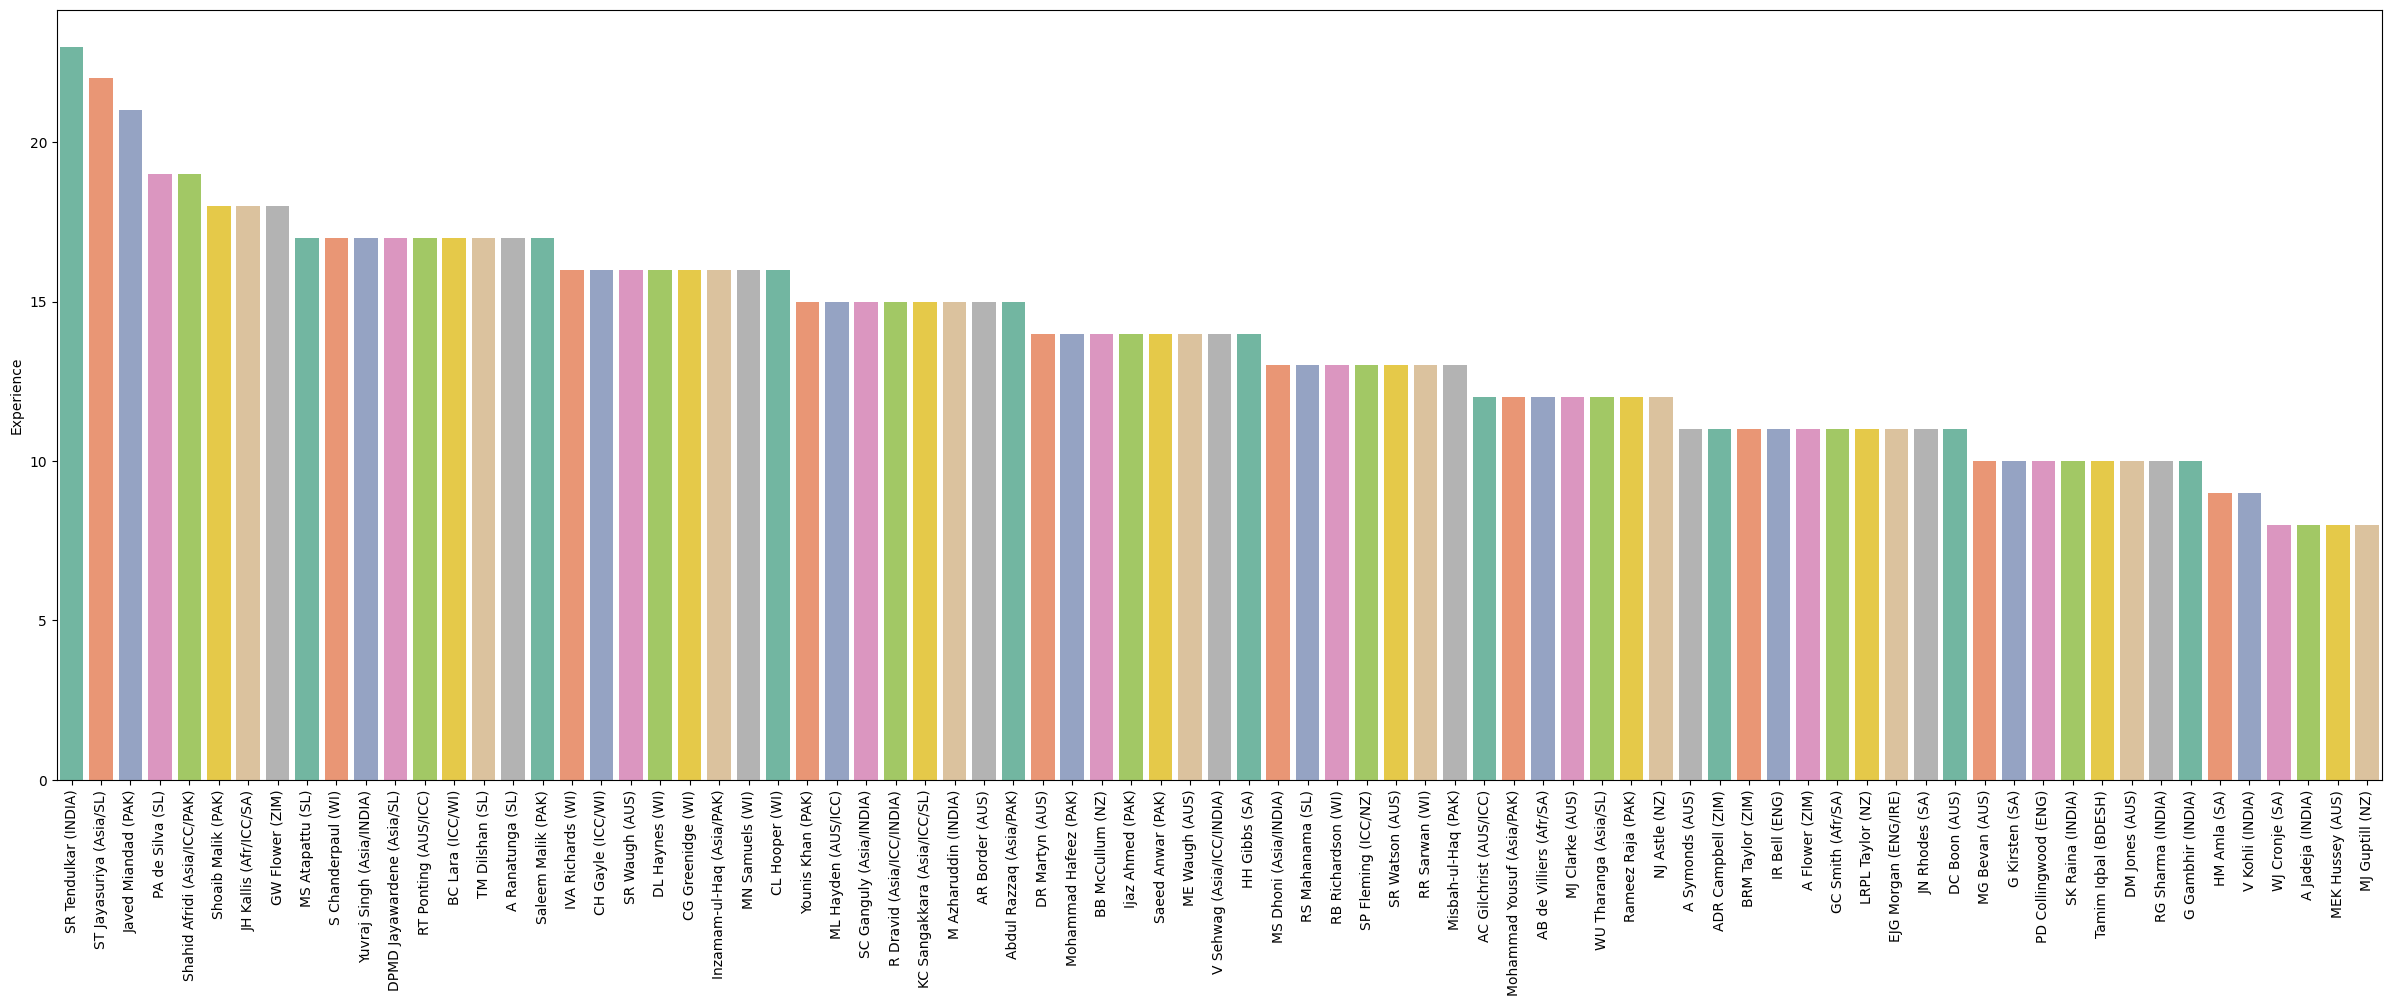

In [48]:
plt.figure(figsize =(30,10))
Exp1 = data[["Player","Experience"]].sort_values("Experience",ascending = False)
ax = sns.barplot(x = "Player",y = "Experience",data = Exp1,palette = "Set2")
ax.set(xlabel = "",ylabel = "Experience")
plt.xticks(rotation = 90)
plt.show()

#Correlation heatmap

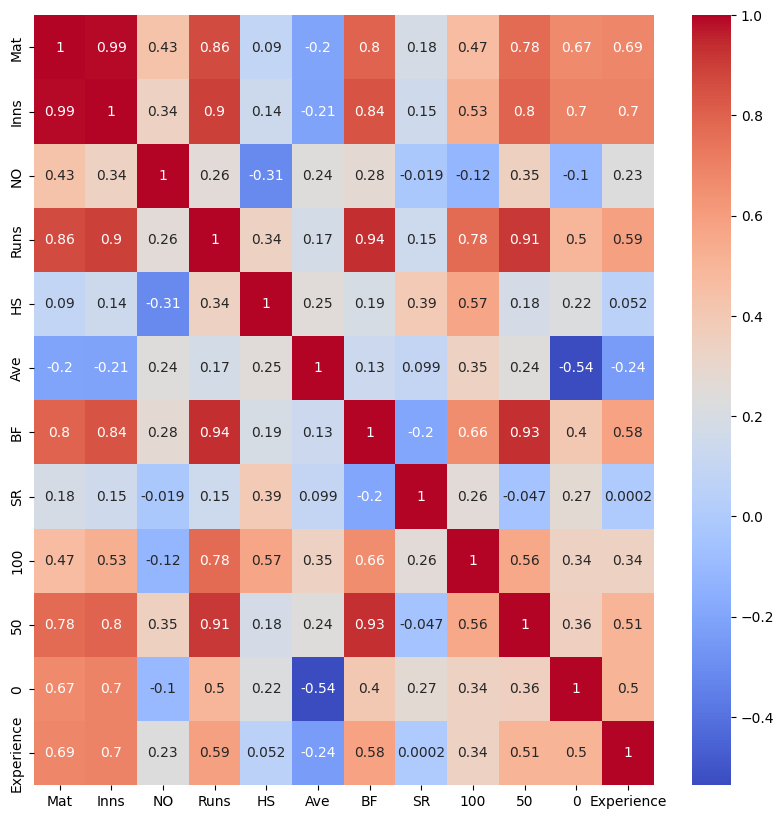

In [49]:
num_col = data.select_dtypes(include = ["int64","float64"])
plt.figure(figsize = (10,10))
sns.heatmap(num_col.corr(),annot = True,cmap = "coolwarm")
plt.savefig("Correlation")
plt.show()

In [50]:
data_copy = data.copy()
player = data_copy.pop("Player")


In [52]:
data_copy.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,463,452,41,18426,200,44.83,21367,86.23,49,96,20,23
1,404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,448,418,39,12650,144,33.37,16020,78.96,19,77,28,17


#Feature Scaling

In [54]:
from sklearn.preprocessing import StandardScaler


In [55]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(data_copy)
df_scaled

array([[ 2.95528204e+00,  3.16933340e+00,  7.64962749e-01,
         4.26232808e+00,  1.63244320e+00,  1.07229395e+00,
         3.68121424e+00,  7.03151526e-01,  4.65672622e+00,
         3.05005720e+00,  1.14583653e+00,  2.81278702e+00],
       [ 2.15517925e+00,  2.13891509e+00,  7.64962749e-01,
         2.60911662e+00,  6.35223595e-01,  5.87724608e-01,
         2.63538469e+00, -4.41394951e-02,  1.67188751e+00,
         2.86541772e+00,  2.96670622e-01,  3.80938324e-01],
       [ 1.76190839e+00,  1.92424461e+00,  6.25396797e-01,
         2.40009894e+00,  4.74381724e-01,  5.96225824e-01,
         2.31965067e+00,  1.10996904e-01,  2.29372891e+00,
         2.18840630e+00,  1.14583653e+00,  9.88900497e-01],
       [ 2.71118288e+00,  2.89741746e+00, -8.40045698e-01,
         2.29204075e+00,  1.27859108e+00, -1.04790945e+00,
         1.58829472e+00,  1.20709133e+00,  2.04499235e+00,
         1.32675540e+00,  3.52350108e+00,  2.50880593e+00],
       [ 2.75186607e+00,  2.68274698e+00,  6.2539679

# Implementing K-Means


In [56]:
from sklearn.cluster import KMeans

#Elbow - Method

In [57]:
# Elbow curve method to find the ideal number of clusters
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters = i,random_state = 42)
  kmeans.fit(df_scaled)
  wcss.append(kmeans.inertia_)



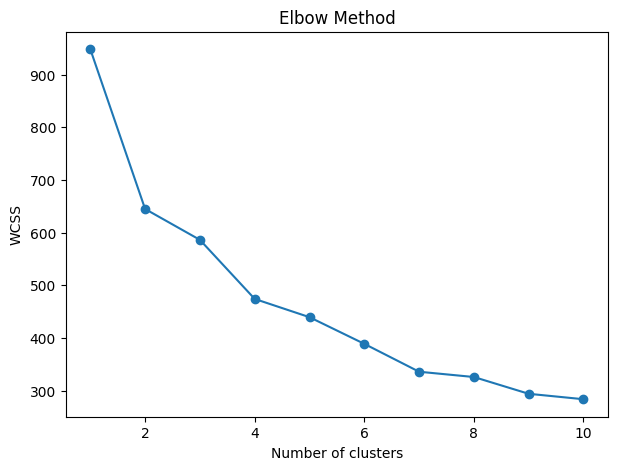

In [59]:
plt.figure(figsize = (7,5))
plt.plot(range(1,11),wcss,marker = "o")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Silhouette Score (Cluster Quality)

In [63]:
from sklearn.metrics import silhouette_score
for k in range(2,10):
  kmeans = KMeans(n_clusters = k,random_state = 42)
  label = kmeans.fit_predict(df_scaled)
  score = silhouette_score(df_scaled,label)
  print("clusters:",k,"silhouette score:",score)

clusters: 2 silhouette score: 0.3091574447649467
clusters: 3 silhouette score: 0.15520162834416676
clusters: 4 silhouette score: 0.20255673617925213
clusters: 5 silhouette score: 0.15330242982129577
clusters: 6 silhouette score: 0.17382902675998232
clusters: 7 silhouette score: 0.18654639312673288
clusters: 8 silhouette score: 0.16806870907043434
clusters: 9 silhouette score: 0.16703597903669365


In [65]:
kmeans = KMeans(n_clusters = 2,random_state = 42)
clusters = kmeans.fit_predict(df_scaled)
data["cluster"] = clusters

In [66]:
data["cluster"].value_counts()

,count
cluster,
1,56
0,23


In [69]:
data.head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience,cluster
0,SR Tendulkar (INDIA),463,452,41,18426,200,44.83,21367,86.23,49,96,20,23,0
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15,0
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17,0
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22,0
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17,0


# 1st Cluster

In [70]:
data[data["cluster"] == 0].sort_values(by = ["NO","Ave","SR"],ascending = [False,False,False]).head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience,cluster
13,MS Dhoni (Asia/INDIA),295,255,70,9496,183,51.32,10706,88.69,10,64,8,13,0
30,SR Waugh (AUS),325,288,58,7569,120,32.90,9971,75.91,3,45,15,16,0
14,M Azharuddin (INDIA),334,308,54,9378,153,36.92,12669,74.02,7,58,9,15,0
6,JH Kallis (Afr/ICC/SA),328,314,53,11579,139,44.36,15885,72.89,17,86,17,18,0
5,Inzamam-ul-Haq (Asia/PAK),378,350,53,11739,137,39.52,15812,74.24,10,83,20,16,0


#2nd cluster

In [72]:
data[data["cluster"] == 1].sort_values(by= ["NO","Ave","SR"],ascending = [False,False,False]).head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience,cluster
38,MG Bevan (AUS),232,196,67,6912,108,53.58,9320,74.16,6,46,5,10,1
78,Abdul Razzaq (Asia/PAK),265,228,57,5080,112,29.70,6252,81.25,3,23,14,15,1
68,DR Martyn (AUS),208,182,51,5346,144,40.80,6877,77.73,5,37,10,14,1
53,JN Rhodes (SA),245,220,51,5935,121,35.11,7336,80.90,2,33,12,11,1
31,A Ranatunga (SL),269,255,47,7456,131,35.84,9571,77.90,4,49,18,17,1


#PCA Visualization

Reduce dimensions for plotting

In [73]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
x_pca = pca.fit_transform(df_scaled)
pca_df = pd.DataFrame(x_pca,columns = ["pc1","pc2"])
pca_df["cluster"] = clusters

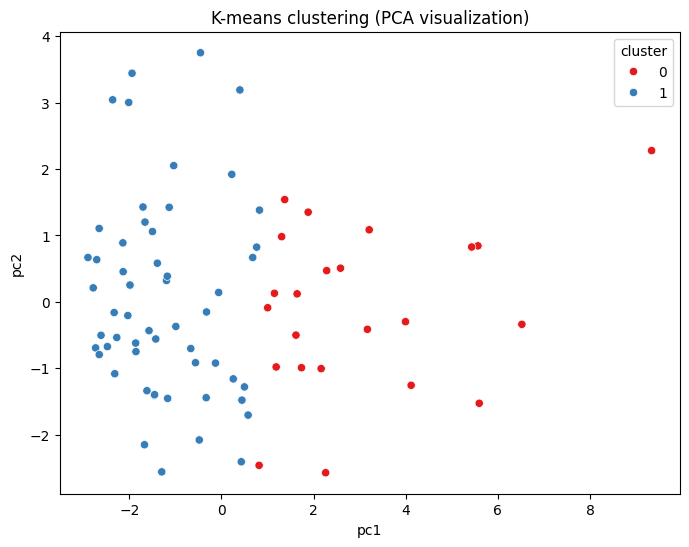

In [74]:
plt.figure(figsize = (8,6))

sns.scatterplot(data=pca_df,x = "pc1",y = "pc2",hue = "cluster",palette = "Set1")
plt.title("K-means clustering (PCA visualization)")
plt.show()